# 🌤️ Full Weather Station Forecasting for STM32
## Multi-Input, Multi-Output: Predict Temperature, Humidity & Pressure

**Model Architecture:**
- **Inputs:** 24 samples × 3 variables (Temperature, Humidity, Pressure)
- **Outputs:** 9 predictions (3 variables × 3 horizons: 1h, 2h, 6h)

**Target deployment:** STM32U585 with X-CUBE-AI

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

c:\Users\lenovo\miniconda3\envs\pytorch_env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.20.0
GPU available: []


In [2]:
# Load and explore data
df = pd.read_csv(r"C:\Users\lenovo\Downloads\archive\jena_climate_2009_2016.csv")
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date Time'].iloc[0]} to {df['Date Time'].iloc[-1]}")
print(f"\nAvailable columns:")
for i, col in enumerate(df.columns):
    print(f"  {i}: {col}")

Dataset shape: (420551, 15)
Date range: 01.01.2009 00:10:00 to 01.01.2017 00:00:00

Available columns:
  0: Date Time
  1: p (mbar)
  2: T (degC)
  3: Tpot (K)
  4: Tdew (degC)
  5: rh (%)
  6: VPmax (mbar)
  7: VPact (mbar)
  8: VPdef (mbar)
  9: sh (g/kg)
  10: H2OC (mmol/mol)
  11: rho (g/m**3)
  12: wv (m/s)
  13: max. wv (m/s)
  14: wd (deg)


In [3]:
# Extract our 3 target variables
# Jena dataset columns:
#   'T (degC)' - Temperature
#   'rh (%)' - Relative Humidity  
#   'p (mbar)' - Pressure

data = df[['T (degC)', 'rh (%)', 'p (mbar)']].copy()
data.columns = ['temperature', 'humidity', 'pressure']

print("Selected variables:")
print(data.describe())

# Check for missing values
print(f"\nMissing values: {data.isnull().sum().sum()}")

Selected variables:
         temperature       humidity       pressure
count  420551.000000  420551.000000  420551.000000
mean        9.450147      76.008259     989.212776
std         8.423365      16.476175       8.358481
min       -23.010000      12.950000     913.600000
25%         3.360000      65.210000     984.200000
50%         9.420000      79.300000     989.580000
75%        15.470000      89.400000     994.720000
max        37.280000     100.000000    1015.350000

Missing values: 0


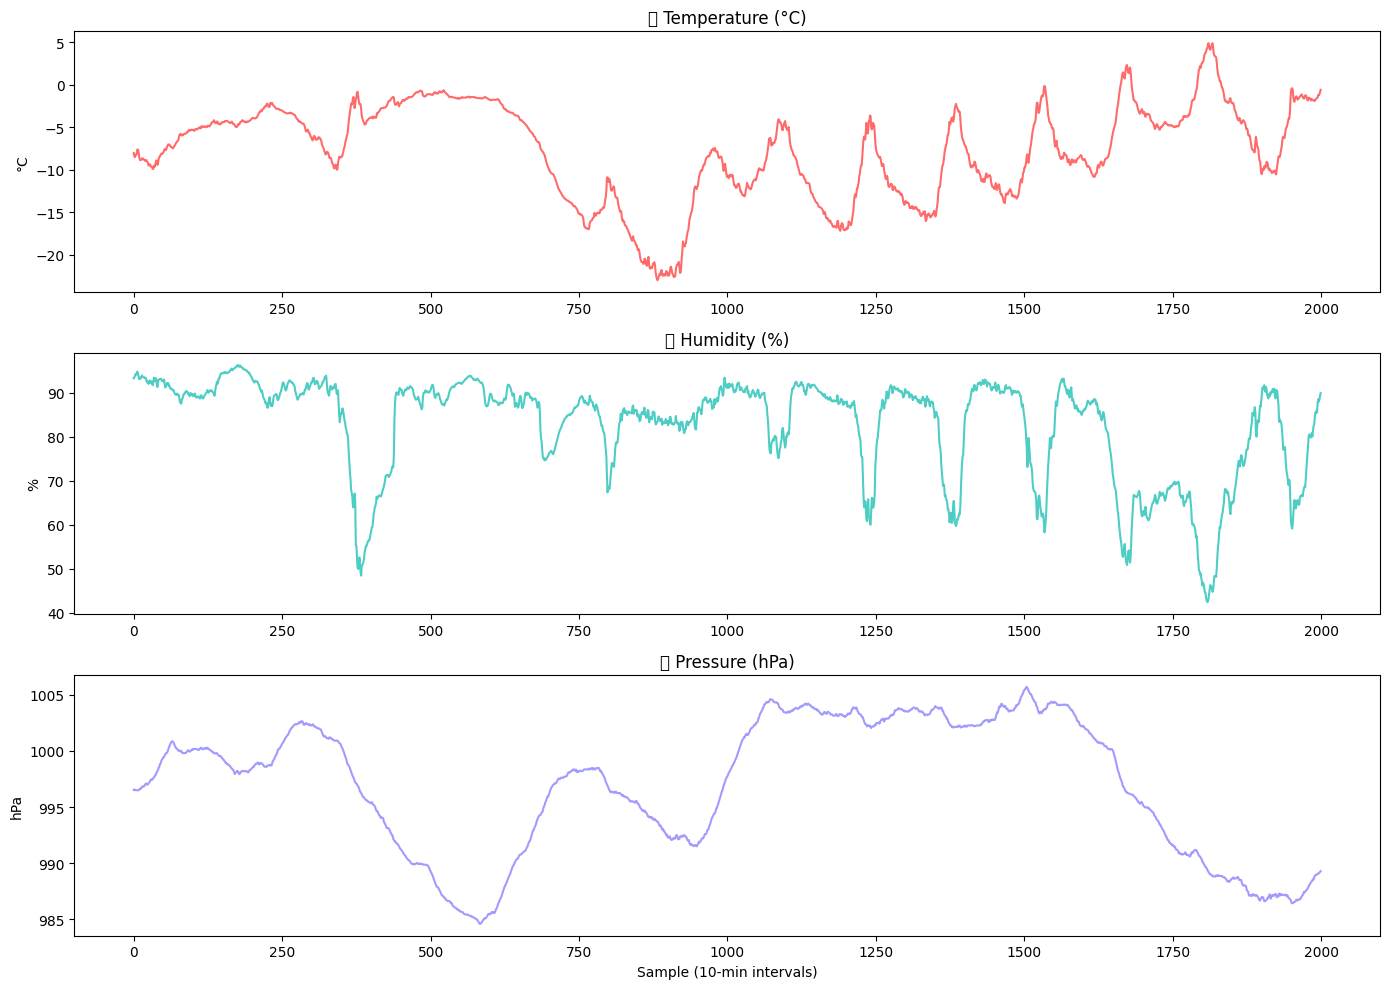

In [4]:
# Visualize the data
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Show first 2000 samples (~2 weeks)
sample_range = range(2000)

axes[0].plot(data['temperature'].iloc[sample_range], color='#ff6b6b')
axes[0].set_title('🌡️ Temperature (°C)')
axes[0].set_ylabel('°C')

axes[1].plot(data['humidity'].iloc[sample_range], color='#4ecdc4')
axes[1].set_title('💧 Humidity (%)')
axes[1].set_ylabel('%')

axes[2].plot(data['pressure'].iloc[sample_range], color='#a29bfe')
axes[2].set_title('🌀 Pressure (hPa)')
axes[2].set_ylabel('hPa')
axes[2].set_xlabel('Sample (10-min intervals)')

plt.tight_layout()
plt.show()

## 2. Data Preprocessing & Dataset Creation

**Configuration:**
- Input: 24 samples × 3 features
- Output: 9 values (3 variables × 3 horizons)

In Jena dataset (10-min intervals):
- 1h ahead = 6 steps
- 2h ahead = 12 steps  
- 6h ahead = 36 steps

In [5]:
# Configuration
INPUT_STEPS = 24              # Input sequence length
FORECAST_STEPS = [6, 12, 36]  # 1h, 2h, 6h in 10-min intervals
NUM_FEATURES = 3              # Temperature, Humidity, Pressure
NUM_OUTPUTS = NUM_FEATURES * len(FORECAST_STEPS)  # 9 outputs

print(f"Input: {INPUT_STEPS} timesteps × {NUM_FEATURES} features")
print(f"Output: {NUM_OUTPUTS} predictions")
print(f"\nForecast horizons:")
for i, step in enumerate(FORECAST_STEPS):
    hours = step * 10 / 60
    print(f"  +{hours:.0f}h: step {step}")

Input: 24 timesteps × 3 features
Output: 9 predictions

Forecast horizons:
  +1h: step 6
  +2h: step 12
  +6h: step 36


In [6]:
# Normalize each variable separately
scalers = {}
data_normalized = pd.DataFrame()

for col in data.columns:
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_normalized[col] = scaler.fit_transform(data[[col]]).flatten()
    scalers[col] = scaler
    print(f"{col}: min={scaler.data_min_[0]:.2f}, max={scaler.data_max_[0]:.2f}")

# Save normalization parameters for STM32
NORM_PARAMS = {
    'temperature': {'min': scalers['temperature'].data_min_[0], 'max': scalers['temperature'].data_max_[0]},
    'humidity': {'min': scalers['humidity'].data_min_[0], 'max': scalers['humidity'].data_max_[0]},
    'pressure': {'min': scalers['pressure'].data_min_[0], 'max': scalers['pressure'].data_max_[0]}
}

temperature: min=-23.01, max=37.28
humidity: min=12.95, max=100.00
pressure: min=913.60, max=1015.35


In [7]:
def create_multivariate_dataset(data, input_steps, forecast_steps):
    """
    Create dataset for multi-input multi-output forecasting.
    
    Args:
        data: DataFrame with normalized values (n_samples, 3)
        input_steps: number of input timesteps (24)
        forecast_steps: list of forecast horizons [6, 12, 36]
    
    Returns:
        X: input sequences (n_samples, input_steps, 3)
        Y: target values (n_samples, 9) 
           [temp_1h, temp_2h, temp_6h, hum_1h, hum_2h, hum_6h, press_1h, press_2h, press_6h]
    """
    X, Y = [], []
    max_forecast = max(forecast_steps)
    values = data.values
    
    for i in range(len(values) - input_steps - max_forecast):
        # Input: 24 timesteps × 3 features
        x = values[i:i + input_steps]
        
        # Output: 9 values
        # Order: [temp_1h, temp_2h, temp_6h, hum_1h, hum_2h, hum_6h, press_1h, press_2h, press_6h]
        y = []
        for feat_idx in range(3):  # For each variable
            for step in forecast_steps:  # For each horizon
                y.append(values[i + input_steps + step - 1, feat_idx])
        
        X.append(x)
        Y.append(y)
    
    return np.array(X), np.array(Y)

# Create dataset
X, Y = create_multivariate_dataset(data_normalized, INPUT_STEPS, FORECAST_STEPS)
print(f"X shape: {X.shape}  (samples, timesteps, features)")
print(f"Y shape: {Y.shape}  (samples, outputs)")
print(f"\nOutput order:")
print("  [0-2]: Temperature 1h, 2h, 6h")
print("  [3-5]: Humidity 1h, 2h, 6h")
print("  [6-8]: Pressure 1h, 2h, 6h")

X shape: (420491, 24, 3)  (samples, timesteps, features)
Y shape: (420491, 9)  (samples, outputs)

Output order:
  [0-2]: Temperature 1h, 2h, 6h
  [3-5]: Humidity 1h, 2h, 6h
  [6-8]: Pressure 1h, 2h, 6h


In [8]:
# Train/validation/test split (70/15/15)
n = len(X)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, Y_train = X[:train_end], Y[:train_end]
X_val, Y_val = X[train_end:val_end], Y[train_end:val_end]
X_test, Y_test = X[val_end:], Y[val_end:]

print(f"Training:   {X_train.shape[0]:,} samples")
print(f"Validation: {X_val.shape[0]:,} samples")
print(f"Test:       {X_test.shape[0]:,} samples")

Training:   294,343 samples
Validation: 63,074 samples
Test:       63,074 samples


## 3. Model Architecture

Conv1D model optimized for STM32 deployment with 9 outputs.

In [10]:
def build_weather_model(input_steps, num_features, num_outputs):
    """
    Build Conv1D model for full weather forecasting.
    Optimized for STM32 deployment.
    
    Input: (24, 3) - 24 timesteps, 3 features
    Output: (9,) - 3 variables × 3 horizons
    """
    model = keras.Sequential([
        # Input layer
        layers.Input(shape=(input_steps, num_features)),
        
        # Conv1D blocks for temporal feature extraction
        layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        
        # Flatten and dense layers
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        
        # Output layer: 9 predictions
        layers.Dense(num_outputs, activation='linear')
    ])
    
    return model

model = build_weather_model(INPUT_STEPS, NUM_FEATURES, NUM_OUTPUTS)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 24, 32)         │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 12, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 6, 64)          │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 6, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,537 (181.79 KB)

 Trainable params: 46,217 (180.54 KB)

 Non-trainable params: 320 (1.25 KB)

In [11]:
# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_weather_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

## 4. Training

In [12]:

*# Train the model
print("🚀 Training started...")
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)
print("✅ Training complete!")

🚀 Training started...
Epoch 1/100
4593/4600 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0496 - mae: 0.1372

4600/4600 ━━━━━━━━━━━━━━━━━━━━ 45s 9ms/step - loss: 0.0183 - mae: 0.0889 - val_loss: 0.0062 - val_mae: 0.0551 - learning_rate: 0.0010
Epoch 2/100
4594/4600 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0067 - mae: 0.0573

4600/4600 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - loss: 0.0064 - mae: 0.0556 - val_loss: 0.0057 - val_mae: 0.0520 - learning_rate: 0.0010
Epoch 3/100
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 40s 9ms/step - loss: 0.0057 - mae: 0.0515 - val_loss: 0.0065 - val_mae: 0.0577 - learning_rate: 0.0010
Epoch 4/100
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 37s 8ms/step - loss: 0.0055 - mae: 0.0500 - val_loss: 0.0064 - val_mae: 0.0558 - learning_rate: 0.0010
Epoch 5/100
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 39s 9ms/step - loss: 0.0054 - mae: 0.0493 - val_loss: 0.0062 - val_mae: 0.0554 - learning_rate: 0.0010
Epoch 6/100
4597/4600 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0053 - mae: 0.0489

4600/4600 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - loss: 0.0053 - mae: 0.0487 - val_loss: 0.0056 - val_mae: 0.0520 - learning_rate: 0.0010
Epoch 7/100
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - loss: 0.0052 - mae: 0.0482 - val_loss: 0.0056 - val_mae: 0.0530 - learning_rate: 0.0010
Epoch 8/100
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 88s 11ms/step - loss: 0.0052 - mae: 0.0478 - val_loss: 0.0059 - val_mae: 0.0524 - learning_rate: 0.0010
Epoch 9/100
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - loss: 0.0051 - mae: 0.0478 - val_loss: 0.0066 - val_mae: 0.0559 - learning_rate: 0.0010
Epoch 10/100
4598/4600 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0051 - mae: 0.0475

4600/4600 ━━━━━━━━━━━━━━━━━━━━ 89s 19ms/step - loss: 0.0051 - mae: 0.0475 - val_loss: 0.0055 - val_mae: 0.0498 - learning_rate: 0.0010
Epoch 11/100
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 95s 21ms/step - loss: 0.0051 - mae: 0.0474 - val_loss: 0.0063 - val_mae: 0.0539 - learning_rate: 0.0010
Epoch 12/100
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 129s 28ms/step - loss: 0.0050 - mae: 0.0472 - val_loss: 0.0058 - val_mae: 0.0524 - learning_rate: 0.0010
Epoch 13/100
4599/4600 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0050 - mae: 0.0471
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 78s 17ms/step - loss: 0.0050 - mae: 0.0471 - val_loss: 0.0059 - val_mae: 0.0532 - learning_rate: 0.0010
Epoch 14/100
4598/4600 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0048 - mae: 0.0462

4600/4600 ━━━━━━━━━━━━━━━━━━━━ 77s 17ms/step - loss: 0.0048 - mae: 0.0460 - val_loss: 0.0052 - val_mae: 0.0493 - learning_rate: 5.0000e-04
Epoch 15/100
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 69s 15ms/step - loss: 0.0048 - mae: 0.0459 - val_loss: 0.0053 - val_mae: 0.0491 - learning_rate: 5.0000e-04
Epoch 16/100
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 71s 15ms/step - loss: 0.0048 - mae: 0.0458 - val_loss: 0.0058 - val_mae: 0.0506 - learning_rate: 5.0000e-04
Epoch 17/100
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 74s 16ms/step - loss: 0.0047 - mae: 0.0457 - val_loss: 0.0059 - val_mae: 0.0535 - learning_rate: 5.0000e-04
Epoch 18/100
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 84s 16ms/step - loss: 0.0047 - mae: 0.0455 - val_loss: 0.0056 - val_mae: 0.0489 - learning_rate: 5.0000e-04
Epoch 19/100
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 78s 16ms/step - loss: 0.0047 - mae: 0.0455 - val_loss: 0.0056 - val_mae: 0.0505 - learning_rate: 5.0000e-04
Epoch 20/100
4600/4600 ━━━━━━━━━━━━━━━━━━━━ 75s 16ms/step - loss: 0.0047 - mae: 0.0455 - val_loss: 0.

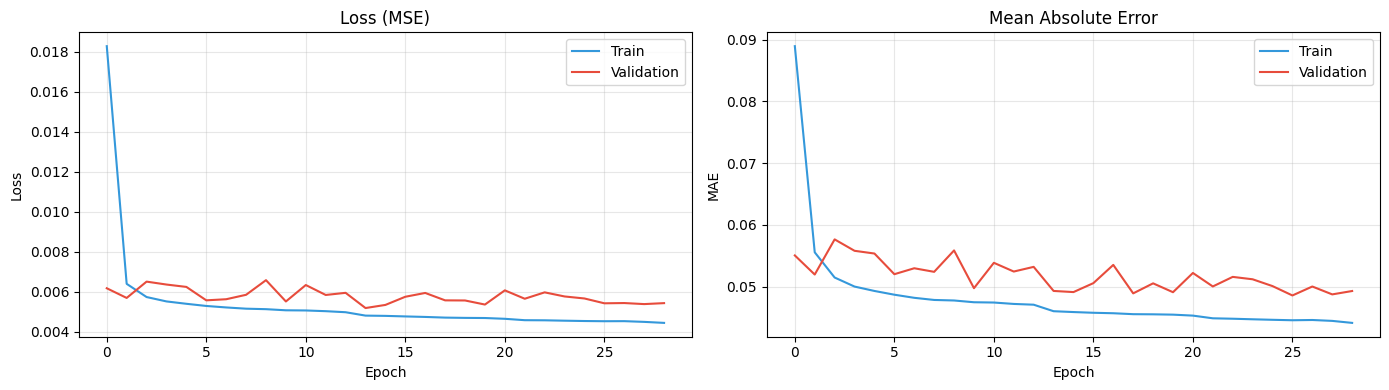

In [13]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Validation', color='#e74c3c')
axes[0].set_title('Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train', color='#3498db')
axes[1].plot(history.history['val_mae'], label='Validation', color='#e74c3c')
axes[1].set_title('Mean Absolute Error')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Evaluation

In [15]:
# Skip this line - comment it out or delete it:
# model = keras.models.load_model('best_weather_model.h5')

# Just run evaluation directly (model already has best weights):
test_loss, test_mae = model.evaluate(X_test, Y_test, verbose=0)
print(f"Test Loss (MSE): {test_loss:.6f}")
print(f"Test MAE (normalized): {test_mae:.6f}")

Test Loss (MSE): 0.004638
Test MAE (normalized): 0.048402


In [16]:
# Make predictions
Y_pred = model.predict(X_test, verbose=0)

# Denormalize function
def denormalize(values, var_name):
    p = NORM_PARAMS[var_name]
    return values * (p['max'] - p['min']) + p['min']

# Calculate metrics for each output
variables = ['temperature', 'humidity', 'pressure']
horizons = ['1h', '2h', '6h']
units = ['°C', '%', 'hPa']

print("\n" + "="*70)
print("                    MODEL PERFORMANCE SUMMARY")
print("="*70)
print(f"{'Variable':<15} {'Horizon':<10} {'RMSE':<15} {'MAE':<15}")
print("-"*70)

results = {}
idx = 0
for var_idx, var in enumerate(variables):
    results[var] = {}
    for h_idx, h in enumerate(horizons):
        y_true = denormalize(Y_test[:, idx], var)
        y_pred = denormalize(Y_pred[:, idx], var)
        
        rmse = np.sqrt(np.mean((y_true - y_pred)**2))
        mae = np.mean(np.abs(y_true - y_pred))
        
        results[var][h] = {'rmse': rmse, 'mae': mae}
        print(f"{var:<15} {h:<10} {rmse:<15.3f} {mae:<15.3f}")
        idx += 1
    print("-"*70)


                    MODEL PERFORMANCE SUMMARY
Variable        Horizon    RMSE            MAE            
----------------------------------------------------------------------
temperature     1h         2.601           2.109          
temperature     2h         2.738           2.219          
temperature     6h         3.840           3.089          
----------------------------------------------------------------------
humidity        1h         5.986           4.511          
humidity        2h         7.077           5.433          
humidity        6h         11.721          9.490          
----------------------------------------------------------------------
pressure        1h         3.759           2.967          
pressure        2h         3.762           2.969          
pressure        6h         4.018           3.155          
----------------------------------------------------------------------


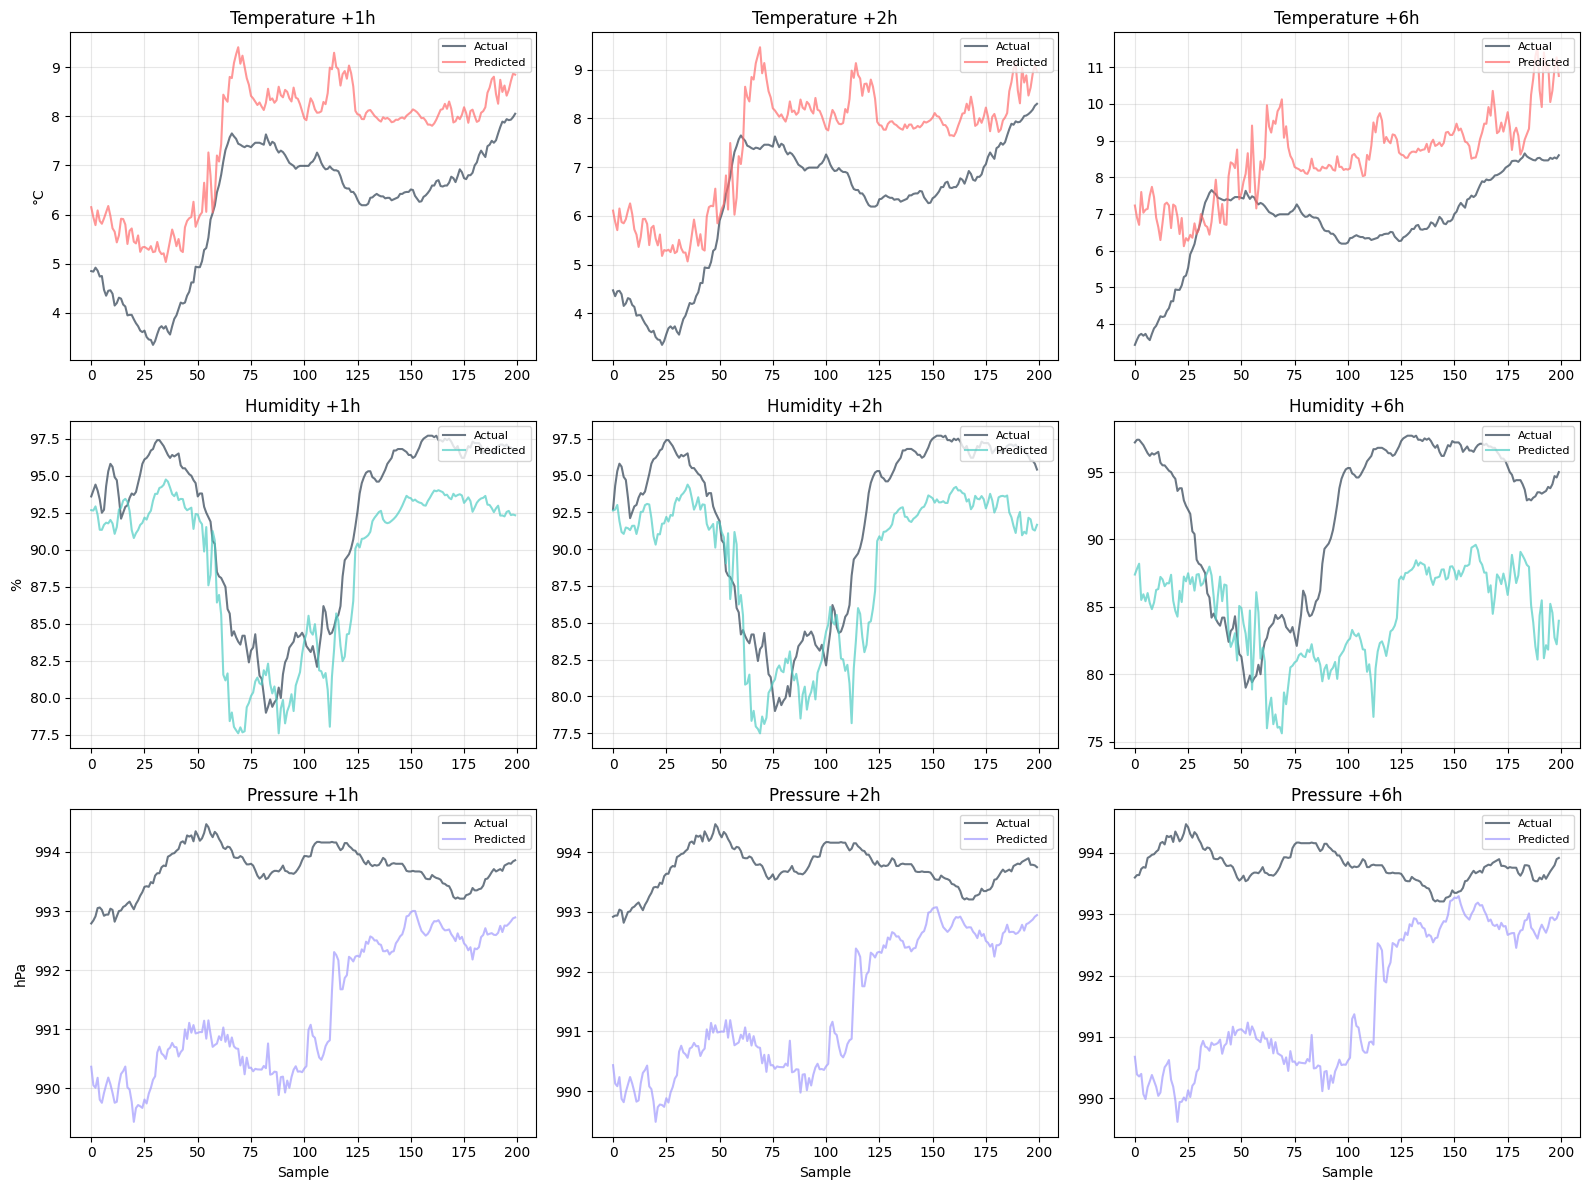

In [17]:
# Visualize predictions for each variable
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

sample_range = range(200, 400)  # Show 200 test samples
colors = {'temperature': '#ff6b6b', 'humidity': '#4ecdc4', 'pressure': '#a29bfe'}

idx = 0
for row, var in enumerate(variables):
    for col, h in enumerate(horizons):
        y_true = denormalize(Y_test[sample_range, idx], var)
        y_pred = denormalize(Y_pred[sample_range, idx], var)
        
        ax = axes[row, col]
        ax.plot(y_true, label='Actual', alpha=0.7, color='#2c3e50')
        ax.plot(y_pred, label='Predicted', alpha=0.7, color=colors[var])
        ax.set_title(f'{var.capitalize()} +{h}')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
        
        if col == 0:
            ax.set_ylabel(units[row])
        if row == 2:
            ax.set_xlabel('Sample')
        
        idx += 1

plt.tight_layout()
plt.show()

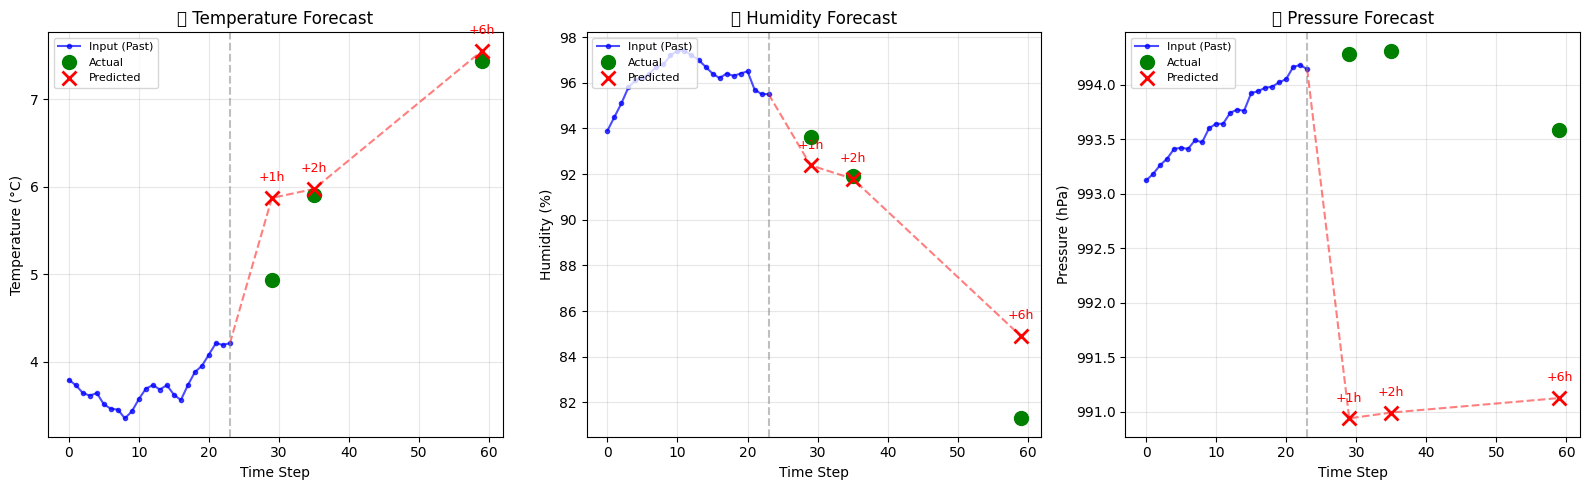


📊 FORECAST EXAMPLE

TEMPERATURE (Current: 4.2°C)
  +1h: Predicted 5.9°C, Actual 4.9°C, Error +0.9°C
  +2h: Predicted 6.0°C, Actual 5.9°C, Error +0.1°C
  +6h: Predicted 7.6°C, Actual 7.4°C, Error +0.1°C

HUMIDITY (Current: 95.5%)
  +1h: Predicted 92.4%, Actual 93.6%, Error -1.2%
  +2h: Predicted 91.8%, Actual 91.9%, Error -0.1%
  +6h: Predicted 84.9%, Actual 81.3%, Error +3.6%

PRESSURE (Current: 994.1hPa)
  +1h: Predicted 990.9hPa, Actual 994.3hPa, Error -3.3hPa
  +2h: Predicted 991.0hPa, Actual 994.3hPa, Error -3.3hPa
  +6h: Predicted 991.1hPa, Actual 993.6hPa, Error -2.5hPa


In [18]:
# Example forecast visualization
sample_idx = 250

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for var_idx, (var, unit) in enumerate(zip(variables, units)):
    ax = axes[var_idx]
    
    # Get input sequence (denormalized)
    input_seq = denormalize(X_test[sample_idx, :, var_idx], var)
    
    # Get predictions and actuals
    pred_values = []
    actual_values = []
    for h_idx in range(3):
        out_idx = var_idx * 3 + h_idx
        pred_values.append(denormalize(Y_pred[sample_idx, out_idx], var))
        actual_values.append(denormalize(Y_test[sample_idx, out_idx], var))
    
    # Plot input
    x_input = range(INPUT_STEPS)
    ax.plot(x_input, input_seq, 'b-o', markersize=3, label='Input (Past)', alpha=0.7)
    
    # Plot forecast points
    x_forecast = [INPUT_STEPS + s - 1 for s in FORECAST_STEPS]
    ax.plot(x_forecast, actual_values, 'go', markersize=10, label='Actual')
    ax.plot(x_forecast, pred_values, 'rx', markersize=10, mew=2, label='Predicted')
    
    # Connect with dashed line
    ax.plot([INPUT_STEPS-1] + x_forecast, [input_seq[-1]] + pred_values, 'r--', alpha=0.5)
    
    # Labels for horizons
    for i, (x, h) in enumerate(zip(x_forecast, horizons)):
        ax.annotate(f'+{h}', (x, pred_values[i]), textcoords="offset points",
                   xytext=(0, 12), ha='center', fontsize=9, color='red')
    
    ax.axvline(x=INPUT_STEPS-1, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Time Step')
    ax.set_ylabel(f'{var.capitalize()} ({unit})')
    ax.set_title(f'{["🌡️", "💧", "🌀"][var_idx]} {var.capitalize()} Forecast')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print forecast details
print("\n📊 FORECAST EXAMPLE")
print("="*60)
for var_idx, (var, unit) in enumerate(zip(variables, units)):
    current = denormalize(X_test[sample_idx, -1, var_idx], var)
    print(f"\n{var.upper()} (Current: {current:.1f}{unit})")
    for h_idx, h in enumerate(horizons):
        out_idx = var_idx * 3 + h_idx
        pred = denormalize(Y_pred[sample_idx, out_idx], var)
        actual = denormalize(Y_test[sample_idx, out_idx], var)
        error = pred - actual
        print(f"  +{h}: Predicted {pred:.1f}{unit}, Actual {actual:.1f}{unit}, Error {error:+.1f}{unit}")

## 6. Convert to TFLite for STM32

In [19]:
# Save Keras model
model.save('weather_forecast_model.h5')
print("✅ Saved: weather_forecast_model.h5")

✅ Saved: weather_forecast_model.h5


In [20]:
# Convert to TFLite (float32)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('weather_forecast_float32.tflite', 'wb') as f:
    f.write(tflite_model)
print(f"✅ Float32 TFLite: {len(tflite_model):,} bytes ({len(tflite_model)/1024:.1f} KB)")

INFO:tensorflow:Assets written to: C:\Users\lenovo\AppData\Local\Temp\tmp8dtz8770\assets


INFO:tensorflow:Assets written to: C:\Users\lenovo\AppData\Local\Temp\tmp8dtz8770\assets


Saved artifact at 'C:\Users\lenovo\AppData\Local\Temp\tmp8dtz8770'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 3), dtype=tf.float32, name='keras_tensor_15')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  2439562294480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562294864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562295248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562296208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562296016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562295440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562295824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562295056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562296592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562296784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562

In [21]:
# Convert to TFLite with quantization (smaller size)
def representative_dataset():
    for i in range(200):
        yield [X_train[i:i+1].astype(np.float32)]

converter_quant = tf.lite.TFLiteConverter.from_keras_model(model)
converter_quant.optimizations = [tf.lite.Optimize.DEFAULT]
converter_quant.representative_dataset = representative_dataset
converter_quant.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_quant.inference_input_type = tf.float32
converter_quant.inference_output_type = tf.float32

try:
    tflite_quant = converter_quant.convert()
    with open('weather_forecast_quant.tflite', 'wb') as f:
        f.write(tflite_quant)
    print(f"✅ Quantized TFLite: {len(tflite_quant):,} bytes ({len(tflite_quant)/1024:.1f} KB)")
    print(f"   Size reduction: {(1 - len(tflite_quant)/len(tflite_model))*100:.1f}%")
except Exception as e:
    print(f"⚠️ Quantization failed: {e}")
    print("   Using float32 model instead.")

INFO:tensorflow:Assets written to: C:\Users\lenovo\AppData\Local\Temp\tmpnyi8wjx6\assets


INFO:tensorflow:Assets written to: C:\Users\lenovo\AppData\Local\Temp\tmpnyi8wjx6\assets


Saved artifact at 'C:\Users\lenovo\AppData\Local\Temp\tmpnyi8wjx6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 3), dtype=tf.float32, name='keras_tensor_15')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  2439562294480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562294864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562295248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562296208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562296016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562295440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562295824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562295056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562296592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562296784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2439562

In [22]:
# Verify TFLite model
interpreter = tf.lite.Interpreter(model_path='weather_forecast_float32.tflite')
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("TFLite Model Details:")
print(f"\nInput:")
print(f"  Shape: {input_details[0]['shape']}")
print(f"  Type: {input_details[0]['dtype']}")
print(f"\nOutput:")
print(f"  Shape: {output_details[0]['shape']}")
print(f"  Type: {output_details[0]['dtype']}")

TFLite Model Details:

Input:
  Shape: [ 1 24  3]
  Type: <class 'numpy.float32'>

Output:
  Shape: [1 9]
  Type: <class 'numpy.float32'>


In [23]:
# Test TFLite inference accuracy
test_input = X_test[0:1].astype(np.float32)

# TFLite inference
interpreter.set_tensor(input_details[0]['index'], test_input)
interpreter.invoke()
tflite_output = interpreter.get_tensor(output_details[0]['index'])

# Keras inference
keras_output = model.predict(test_input, verbose=0)

print("Inference Comparison (first sample):")
print(f"\nKeras output:  {keras_output[0][:3]}... (showing first 3)")
print(f"TFLite output: {tflite_output[0][:3]}... (showing first 3)")
print(f"\nMax difference: {np.abs(keras_output - tflite_output).max():.8f}")
print("✅ TFLite conversion verified!" if np.abs(keras_output - tflite_output).max() < 1e-5 else "⚠️ Check conversion")

Inference Comparison (first sample):

Keras output:  [0.49685848 0.4952789  0.50997144]... (showing first 3)
TFLite output: [0.49685845 0.49527887 0.50997144]... (showing first 3)

Max difference: 0.00000018
✅ TFLite conversion verified!


## 7. Generate STM32 Configuration

In [24]:
# Generate C header content for STM32
stm32_config = f"""
/*******************************************************************************
 * WEATHER FORECAST MODEL - STM32 CONFIGURATION
 * Auto-generated from training notebook
 ******************************************************************************/

#ifndef WEATHER_FORECAST_CONFIG_H
#define WEATHER_FORECAST_CONFIG_H

/* Model Input/Output Configuration */
#define INPUT_SAMPLES       {INPUT_STEPS}
#define INPUT_FEATURES      {NUM_FEATURES}
#define NUM_OUTPUTS         {NUM_OUTPUTS}

/* Normalization Parameters */
// Temperature
#define TEMP_MIN    {NORM_PARAMS['temperature']['min']:.6f}f
#define TEMP_MAX    {NORM_PARAMS['temperature']['max']:.6f}f

// Humidity
#define HUM_MIN     {NORM_PARAMS['humidity']['min']:.6f}f
#define HUM_MAX     {NORM_PARAMS['humidity']['max']:.6f}f

// Pressure
#define PRESS_MIN   {NORM_PARAMS['pressure']['min']:.6f}f
#define PRESS_MAX   {NORM_PARAMS['pressure']['max']:.6f}f

/* Output Index Mapping */
// Temperature forecasts
#define IDX_TEMP_1H     0
#define IDX_TEMP_2H     1
#define IDX_TEMP_6H     2

// Humidity forecasts  
#define IDX_HUM_1H      3
#define IDX_HUM_2H      4
#define IDX_HUM_6H      5

// Pressure forecasts
#define IDX_PRESS_1H    6
#define IDX_PRESS_2H    7
#define IDX_PRESS_6H    8

/* Normalization Functions */
static inline float normalize_temp(float temp) {{
    return (temp - TEMP_MIN) / (TEMP_MAX - TEMP_MIN);
}}

static inline float normalize_hum(float hum) {{
    return (hum - HUM_MIN) / (HUM_MAX - HUM_MIN);
}}

static inline float normalize_press(float press) {{
    return (press - PRESS_MIN) / (PRESS_MAX - PRESS_MIN);
}}

static inline float denormalize_temp(float norm) {{
    return norm * (TEMP_MAX - TEMP_MIN) + TEMP_MIN;
}}

static inline float denormalize_hum(float norm) {{
    return norm * (HUM_MAX - HUM_MIN) + HUM_MIN;
}}

static inline float denormalize_press(float norm) {{
    return norm * (PRESS_MAX - PRESS_MIN) + PRESS_MIN;
}}

#endif /* WEATHER_FORECAST_CONFIG_H */
"""

# Save to file
with open('weather_forecast_config.h', 'w') as f:
    f.write(stm32_config)

print(stm32_config)


/*******************************************************************************
 * WEATHER FORECAST MODEL - STM32 CONFIGURATION
 * Auto-generated from training notebook
 ******************************************************************************/

#ifndef WEATHER_FORECAST_CONFIG_H
#define WEATHER_FORECAST_CONFIG_H

/* Model Input/Output Configuration */
#define INPUT_SAMPLES       24
#define INPUT_FEATURES      3
#define NUM_OUTPUTS         9

/* Normalization Parameters */
// Temperature
#define TEMP_MIN    -23.010000f
#define TEMP_MAX    37.280000f

// Humidity
#define HUM_MIN     12.950000f
#define HUM_MAX     100.000000f

// Pressure
#define PRESS_MIN   913.600000f
#define PRESS_MAX   1015.350000f

/* Output Index Mapping */
// Temperature forecasts
#define IDX_TEMP_1H     0
#define IDX_TEMP_2H     1
#define IDX_TEMP_6H     2

// Humidity forecasts  
#define IDX_HUM_1H      3
#define IDX_HUM_2H      4
#define IDX_HUM_6H      5

// Pressure forecasts
#define IDX_PRESS_1H    6
#

In [25]:
# Print expected model performance for documentation
print("\n" + "="*70)
print("            EXPECTED MODEL PERFORMANCE (for documentation)")
print("="*70)
print(f"\n{'Variable':<15} {'1h RMSE':<12} {'2h RMSE':<12} {'6h RMSE':<12}")
print("-"*70)
for var, unit in zip(variables, units):
    r1 = results[var]['1h']['rmse']
    r2 = results[var]['2h']['rmse']
    r6 = results[var]['6h']['rmse']
    print(f"{var:<15} {r1:.2f} {unit:<8} {r2:.2f} {unit:<8} {r6:.2f} {unit}")


            EXPECTED MODEL PERFORMANCE (for documentation)

Variable        1h RMSE      2h RMSE      6h RMSE     
----------------------------------------------------------------------
temperature     2.60 °C       2.74 °C       3.84 °C
humidity        5.99 %        7.08 %        11.72 %
pressure        3.76 hPa      3.76 hPa      4.02 hPa


## 8. Summary

### 🎯 Model Architecture
```
Input: (24, 3) → Conv1D(32) → Conv1D(64) → Conv1D(64) → Dense(64) → Dense(32) → Output: (9)
```

### 📊 Input/Output Mapping
```
INPUTS (24 samples × 3 features):
  - [:, 0] = Temperature history
  - [:, 1] = Humidity history
  - [:, 2] = Pressure history

OUTPUTS (9 predictions):
  - [0, 1, 2] = Temperature @ 1h, 2h, 6h
  - [3, 4, 5] = Humidity @ 1h, 2h, 6h  
  - [6, 7, 8] = Pressure @ 1h, 2h, 6h
```

### 📁 Generated Files
| File | Description |
|------|-------------|
| `weather_forecast_float32.tflite` | Main model for X-CUBE-AI |
| `weather_forecast_quant.tflite` | Quantized (smaller) version |
| `weather_forecast_config.h` | STM32 configuration header |
| `weather_forecast_model.h5` | Keras model (backup) |

### 🚀 Next Steps
1. Import `weather_forecast_float32.tflite` into STM32CubeMX
2. Add `weather_forecast_config.h` to your project
3. Update `ai_inference.c` for 3-input, 9-output model
4. Update dashboard to display full weather forecast